In [60]:
import pandas as pd

In [61]:
train_df = pd.read_csv(
    "train_data.txt",
    sep=" ::: ",
    header=None,
    names=["ID", "TITLE", "GENRE", "DESCRIPTION"],
    engine="python"
)

train_df.head()

,ID,TITLE,GENRE,DESCRIPTION
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends meet...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...


In [62]:
print("Rows and Columns:", train_df.shape)

Rows and Columns: (54214, 4)


In [63]:
train_df.isnull().sum()

,0
ID,0
TITLE,0
GENRE,0
DESCRIPTION,0


In [64]:
train_df["GENRE"].value_counts().head(10)

,count
GENRE,
drama,13613
documentary,13096
comedy,7447
short,5073
horror,2204
thriller,1591
action,1315
western,1032
reality-tv,884


In [65]:
train_df["DESCRIPTION"].str.len().describe()

,DESCRIPTION
count,54214.000000
mean,599.452429
std,446.026620
min,41.000000
25%,324.000000
50%,463.000000
75%,712.000000
max,10503.000000


In [66]:
train_df["desc_length"] = train_df["DESCRIPTION"].str.len()

train_df.head()

,ID,TITLE,GENRE,DESCRIPTION,desc_length
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...,545
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous re...,183
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...,649
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends meet...,1081
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...,624


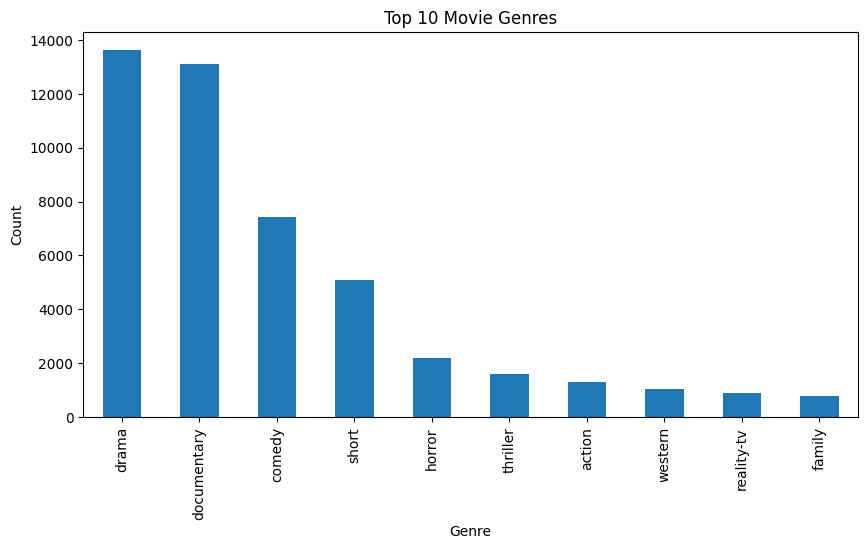

In [67]:
import matplotlib.pyplot as plt

genre_counts = train_df["GENRE"].value_counts().head(10)

plt.figure(figsize=(10,5))
genre_counts.plot(kind="bar")

plt.title("Top 10 Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.show()

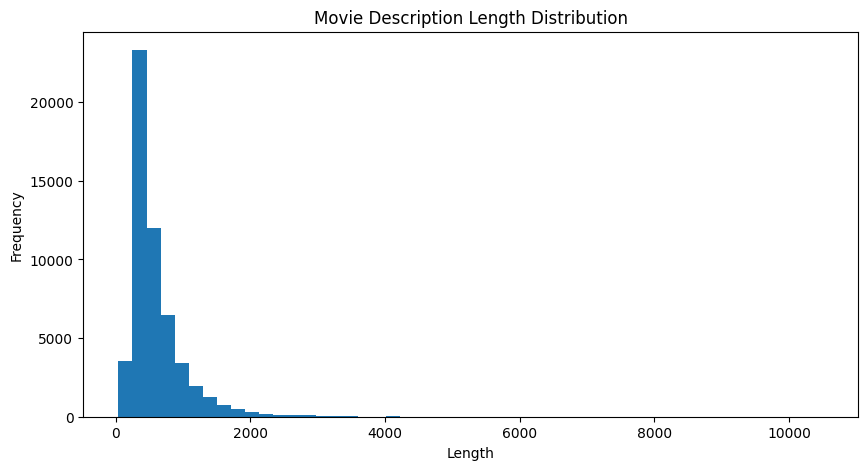

In [68]:
plt.figure(figsize=(10,5))

plt.hist(train_df["desc_length"], bins=50)

plt.title("Movie Description Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")

plt.show()

In [69]:
print("Number of unique genres:", train_df["GENRE"].nunique())

Number of unique genres: 27


In [70]:
print(sorted(train_df["GENRE"].unique()))

['action', 'adult', 'adventure', 'animation', 'biography', 'comedy', 'crime', 'documentary', 'drama', 'family', 'fantasy', 'game-show', 'history', 'horror', 'music', 'musical', 'mystery', 'news', 'reality-tv', 'romance', 'sci-fi', 'short', 'sport', 'talk-show', 'thriller', 'war', 'western']


In [71]:
X = train_df["DESCRIPTION"]

y = train_df["GENRE"]

print(X.head())
print(y.head())

0    Listening in to a conversation between his doc...
1    A brother and sister with a past incestuous re...
2    As the bus empties the students for their fiel...
3    To help their unemployed father make ends meet...
4    The film's title refers not only to the un-rec...
Name: DESCRIPTION, dtype: object
0       drama
1    thriller
2       adult
3       drama
4       drama
Name: GENRE, dtype: object


In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 43371
Testing samples: 10843


In [73]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [74]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

In [75]:
X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [76]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (43371, 5000)
Testing TF-IDF shape: (10843, 5000)


In [77]:
print(tfidf.get_feature_names_out()[:20])

['000' '10' '100' '1000' '11' '12' '13' '14' '15' '150' '16' '17' '18'
 '19' '1930' '1930s' '1940' '1944' '1950' '1950s']


In [78]:
print(tfidf.get_feature_names_out()[100:120])

['abusive' 'academic' 'academy' 'accept' 'acceptance' 'accepted'
 'accepting' 'accepts' 'access' 'accident' 'accidentally' 'acclaimed'
 'accompanied' 'accompanies' 'accompany' 'accomplished' 'according'
 'account' 'accounts' 'accused']


In [79]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

In [80]:
nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [81]:
y_pred_nb = nb_model.predict(X_test_tfidf)

In [82]:
from sklearn.metrics import accuracy_score

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.5231946878170248


In [83]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

      action       0.58      0.08      0.14       263
       adult       0.88      0.06      0.12       112
   adventure       0.29      0.03      0.05       139
   animation       0.00      0.00      0.00       104
   biography       0.00      0.00      0.00        61
      comedy       0.51      0.44      0.47      1443
       crime       0.00      0.00      0.00       107
 documentary       0.58      0.88      0.70      2659
       drama       0.46      0.83      0.59      2697
      family       1.00      0.01      0.01       150
     fantasy       0.00      0.00      0.00        74
   game-show       1.00      0.15      0.26        40
     history       0.00      0.00      0.00        45
      horror       0.73      0.36      0.48       431
       music       0.77      0.12      0.20       144
     musical       0.00      0.00      0.00        50
     mystery       0.00      0.00      0.00        56
        news       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


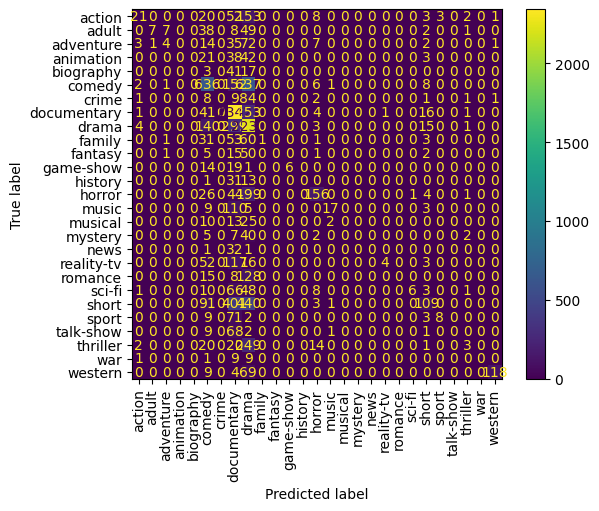

In [84]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_nb,
    xticks_rotation=90
)

plt.show()

In [85]:
from sklearn.linear_model import LogisticRegression

In [86]:
lr_model = LogisticRegression(
    max_iter=1000
)

In [31]:
lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [32]:
y_pred_lr = lr_model.predict(X_test_tfidf)

In [33]:
lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.5446351187380829


In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

      action       0.49      0.15      0.23       140
       adult       0.56      0.07      0.13        68
   adventure       0.64      0.09      0.16        97
   animation       0.00      0.00      0.00        51
   biography       0.00      0.00      0.00        34
      comedy       0.45      0.53      0.49       774
       crime       0.00      0.00      0.00        59
 documentary       0.63      0.85      0.72      1407
       drama       0.50      0.77      0.61      1416
      family       0.29      0.02      0.04        86
     fantasy       0.00      0.00      0.00        36
   game-show       1.00      0.53      0.69        17
     history       0.00      0.00      0.00        11
      horror       0.65      0.49      0.56       211
       music       0.69      0.44      0.54        77
     musical       0.00      0.00      0.00        18
     mystery       0.00      0.00      0.00        38
        news       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [35]:
print("Naive Bayes Accuracy:", nb_accuracy)
print("Logistic Regression Accuracy:", lr_accuracy)

Naive Bayes Accuracy: 0.48864621251516727
Logistic Regression Accuracy: 0.5446351187380829


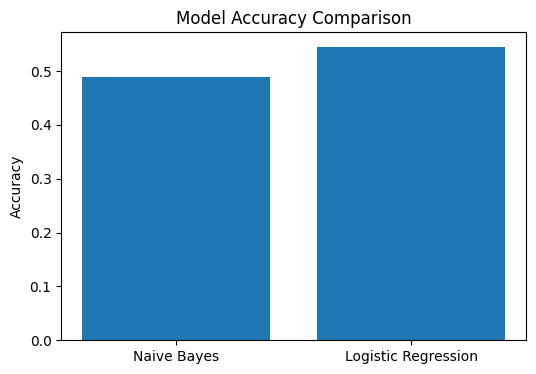

In [36]:
import matplotlib.pyplot as plt

models = ["Naive Bayes", "Logistic Regression"]
scores = [nb_accuracy, lr_accuracy]

plt.figure(figsize=(6,4))
plt.bar(models, scores)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

In [37]:
print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.5446351187380829


In [38]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

LinearSVC()

In [39]:
y_pred_svm = svm_model.predict(X_test_tfidf)

In [40]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.5347547235222743


In [41]:
print("Naive Bayes:", nb_accuracy)
print("Logistic Regression:", lr_accuracy)
print("SVM:", svm_accuracy)

Naive Bayes: 0.48864621251516727
Logistic Regression: 0.5446351187380829
SVM: 0.5347547235222743


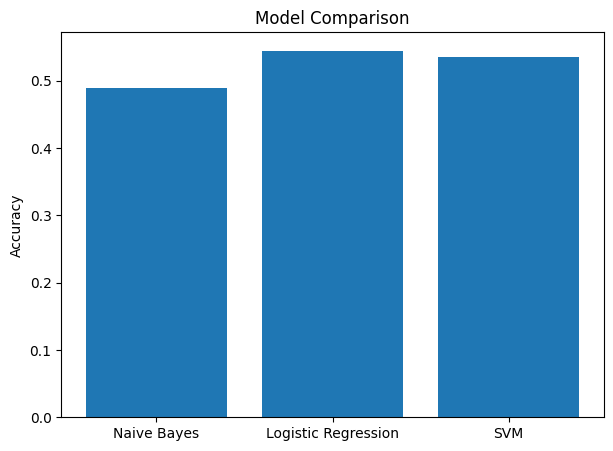

In [42]:
models = ["Naive Bayes", "Logistic Regression", "SVM"]
scores = [nb_accuracy, lr_accuracy, svm_accuracy]

plt.figure(figsize=(7,5))
plt.bar(models, scores)

plt.title("Model Comparison")
plt.ylabel("Accuracy")

plt.show()

In [43]:
def predict_genre(text):
    text_tfidf = tfidf.transform([text])
    prediction = lr_model.predict(text_tfidf)
    return prediction[0]

In [44]:
predict_genre(
    "A serial killer stalks victims in a haunted town."
)

'horror'

In [45]:
import pickle

pickle.dump(lr_model, open("genre_model.pkl", "wb"))
pickle.dump(tfidf, open("tfidf_vectorizer.pkl", "wb"))

In [46]:
from sklearn.svm import LinearSVC

In [47]:
svm_model = LinearSVC()

In [48]:
svm_model.fit(X_train_tfidf, y_train)

LinearSVC()

In [49]:
y_pred_svm = svm_model.predict(X_test_tfidf)

In [50]:
from sklearn.metrics import accuracy_score

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.5347547235222743


In [51]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

      action       0.33      0.24      0.27       140
       adult       0.35      0.18      0.24        68
   adventure       0.37      0.19      0.25        97
   animation       0.34      0.20      0.25        51
   biography       0.00      0.00      0.00        34
      comedy       0.47      0.52      0.50       774
       crime       0.33      0.07      0.11        59
 documentary       0.66      0.79      0.72      1407
       drama       0.53      0.67      0.59      1416
      family       0.24      0.09      0.13        86
     fantasy       0.13      0.06      0.08        36
   game-show       0.71      0.59      0.65        17
     history       0.00      0.00      0.00        11
      horror       0.54      0.56      0.55       211
       music       0.56      0.53      0.55        77
     musical       0.00      0.00      0.00        18
     mystery       0.20      0.03      0.05        38
        news       0.25    

In [52]:
print("Naive Bayes:", nb_accuracy)
print("Logistic Regression:", lr_accuracy)
print("SVM:", svm_accuracy)

Naive Bayes: 0.48864621251516727
Logistic Regression: 0.5446351187380829
SVM: 0.5347547235222743


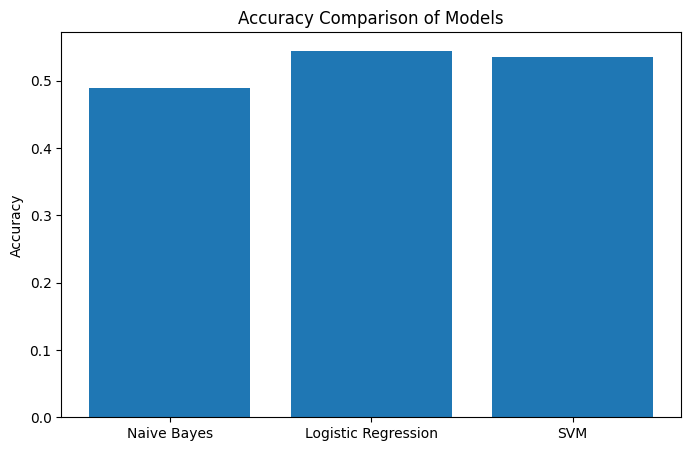

In [53]:
import matplotlib.pyplot as plt

models = ["Naive Bayes", "Logistic Regression", "SVM"]
scores = [nb_accuracy, lr_accuracy, svm_accuracy]

plt.figure(figsize=(8,5))
plt.bar(models, scores)

plt.title("Accuracy Comparison of Models")
plt.ylabel("Accuracy")

plt.show()

In [54]:
def predict_genre(description):
    description_tfidf = tfidf.transform([description])
    prediction = lr_model.predict(description_tfidf)
    return prediction[0]

In [55]:
predict_genre(
    "A haunted house is terrorized by evil spirits and mysterious murders."
)

'horror'

In [56]:
predict_genre(
    "Two friends go on a hilarious road trip full of funny situations."
)

'comedy'

In [57]:
predict_genre(
    "A haunted house is terrorized by evil spirits and mysterious murders."
)

'horror'

In [58]:
predict_genre(
    "A documentary exploring wildlife conservation and environmental challenges."
)

'documentary'

In [59]:
import pickle

pickle.dump(lr_model, open("movie_genre_model.pkl", "wb"))
pickle.dump(tfidf, open("tfidf_vectorizer.pkl", "wb"))

print("Model Saved Successfully!")

Model Saved Successfully!


In [87]:
import pickle

pickle.dump(lr_model, open("movie_genre_model.pkl", "wb"))
pickle.dump(tfidf, open("tfidf_vectorizer.pkl", "wb"))

print("Model Saved Successfully!")

Model Saved Successfully!
